## Data Profiling

> ### load the required library

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import zscore
import seaborn as sns

> ### define the path and read the dataset 

In [2]:
data_path_sierraleone = "C:\\Users\\girma\\OneDrive\\Desktop\\10 Academy\\week-1\\solar-challenge-week-1\\data\\sierraleone-bumbuna.csv"
data_path_benin       =  "C:\\Users\\girma\\OneDrive\\Desktop\\10 Academy\\week-1\\solar-challenge-week-1\\data\\benin-malanville.csv"
data_path_togo       =  "C:\\Users\\girma\\OneDrive\\Desktop\\10 Academy\\week-1\\solar-challenge-week-1\\data\\togo-dapaong_qc.csv"

benin = pd.read_csv(data_path_benin )
sierraleone = pd.read_csv(data_path_sierraleone)
togo = pd.read_csv(data_path_togo)

> ### Makesure the Timestamp in the correct datetime format

In [5]:
benin['Timestamp'] = pd.to_datetime(benin['Timestamp'])
sierraleone['Timestamp'] = pd.to_datetime(sierraleone['Timestamp'])
togo['Timestamp'] = pd.to_datetime(togo['Timestamp'])

> ### View first few rows

> ### `Sierraleone solar dataset `

In [12]:
sierraleone.head()

,Timestamp,GHI,DNI,DHI,ModA,ModB,Tamb,RH,WS,WSgust,WSstdev,WD,WDstdev,BP,Cleaning,Precipitation,TModA,TModB,Comments
0,2021-10-30 00:01:00,-0.7,-0.1,-0.8,0.0,0.0,21.9,99.1,0.0,0.0,0.0,0.0,0.0,1002,0,0.0,22.3,22.6,NaN
1,2021-10-30 00:02:00,-0.7,-0.1,-0.8,0.0,0.0,21.9,99.2,0.0,0.0,0.0,0.0,0.0,1002,0,0.0,22.3,22.6,NaN
2,2021-10-30 00:03:00,-0.7,-0.1,-0.8,0.0,0.0,21.9,99.2,0.0,0.0,0.0,0.0,0.0,1002,0,0.0,22.3,22.6,NaN
3,2021-10-30 00:04:00,-0.7,0.0,-0.8,0.0,0.0,21.9,99.3,0.0,0.0,0.0,0.0,0.0,1002,0,0.1,22.3,22.6,NaN
4,2021-10-30 00:05:00,-0.7,-0.1,-0.8,0.0,0.0,21.9,99.3,0.0,0.0,0.0,0.0,0.0,1002,0,0.0,22.3,22.6,NaN


> ### `Benin solar dataset `

In [9]:
benin.head()

,Timestamp,GHI,DNI,DHI,ModA,ModB,Tamb,RH,WS,WSgust,WSstdev,WD,WDstdev,BP,Cleaning,Precipitation,TModA,TModB,Comments
0,2021-08-09 00:01:00,-1.2,-0.2,-1.1,0.0,0.0,26.2,93.4,0.0,0.4,0.1,122.1,0.0,998,0,0.0,26.3,26.2,NaN
1,2021-08-09 00:02:00,-1.1,-0.2,-1.1,0.0,0.0,26.2,93.6,0.0,0.0,0.0,0.0,0.0,998,0,0.0,26.3,26.2,NaN
2,2021-08-09 00:03:00,-1.1,-0.2,-1.1,0.0,0.0,26.2,93.7,0.3,1.1,0.5,124.6,1.5,997,0,0.0,26.4,26.2,NaN
3,2021-08-09 00:04:00,-1.1,-0.1,-1.0,0.0,0.0,26.2,93.3,0.2,0.7,0.4,120.3,1.3,997,0,0.0,26.4,26.3,NaN
4,2021-08-09 00:05:00,-1.0,-0.1,-1.0,0.0,0.0,26.2,93.3,0.1,0.7,0.3,113.2,1.0,997,0,0.0,26.4,26.3,NaN


> ### `Togo solar dataset `

In [11]:
togo.head()

,Timestamp,GHI,DNI,DHI,ModA,ModB,Tamb,RH,WS,WSgust,WSstdev,WD,WDstdev,BP,Cleaning,Precipitation,TModA,TModB,Comments
0,2021-10-25 00:01:00,-1.3,0.0,0.0,0.0,0.0,24.8,94.5,0.9,1.1,0.4,227.6,1.1,977,0,0.0,24.7,24.4,NaN
1,2021-10-25 00:02:00,-1.3,0.0,0.0,0.0,0.0,24.8,94.4,1.1,1.6,0.4,229.3,0.7,977,0,0.0,24.7,24.4,NaN
2,2021-10-25 00:03:00,-1.3,0.0,0.0,0.0,0.0,24.8,94.4,1.2,1.4,0.3,228.5,2.9,977,0,0.0,24.7,24.4,NaN
3,2021-10-25 00:04:00,-1.2,0.0,0.0,0.0,0.0,24.8,94.3,1.2,1.6,0.3,229.1,4.6,977,0,0.0,24.7,24.4,NaN
4,2021-10-25 00:05:00,-1.2,0.0,0.0,0.0,0.0,24.8,94.0,1.3,1.6,0.4,227.5,1.6,977,0,0.0,24.7,24.4,NaN


> ### Check data types and values of the datatypes

In [16]:
sierraleone.info(); benin.info();togo.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 525600 entries, 0 to 525599
Data columns (total 19 columns):
 #   Column         Non-Null Count   Dtype         
---  ------         --------------   -----         
 0   Timestamp      525600 non-null  datetime64[ns]
 1   GHI            525600 non-null  float64       
 2   DNI            525600 non-null  float64       
 3   DHI            525600 non-null  float64       
 4   ModA           525600 non-null  float64       
 5   ModB           525600 non-null  float64       
 6   Tamb           525600 non-null  float64       
 7   RH             525600 non-null  float64       
 8   WS             525600 non-null  float64       
 9   WSgust         525600 non-null  float64       
 10  WSstdev        525600 non-null  float64       
 11  WD             525600 non-null  float64       
 12  WDstdev        525600 non-null  float64       
 13  BP             525600 non-null  int64         
 14  Cleaning       525600 non-null  int64         
 15  

## Summary Statistics & Missing-Value Analysis

> ### summary statistics for numeric columns

> ### `Summary statististic for Sierraleone Solar Dataset`

In [18]:
sierraleone.describe().T

,count,mean,min,25%,50%,75%,max,std
Timestamp,525600,2022-04-30 12:00:30.000000768,2021-10-30 00:01:00,2022-01-29 06:00:45,2022-04-30 12:00:30,2022-07-30 18:00:15,2022-10-30 00:00:00,NaN
GHI,525600.0,201.957515,-19.5,-2.8,0.3,362.4,1499.0,298.49515
DNI,525600.0,116.376337,-7.8,-0.3,-0.1,107.0,946.0,218.652659
DHI,525600.0,113.720571,-17.9,-3.8,-0.1,224.7,892.0,158.946032
ModA,525600.0,206.643095,0.0,0.0,3.6,359.5,1507.0,300.896893
ModB,525600.0,198.114691,0.0,0.0,3.4,345.4,1473.0,288.889073
Tamb,525600.0,26.319394,12.3,23.1,25.3,29.4,39.9,4.398605
RH,525600.0,79.448857,9.9,68.7,85.4,96.7,100.0,20.520775
WS,525600.0,1.146113,0.0,0.0,0.8,2.0,19.2,1.239248
WSgust,525600.0,1.691606,0.0,0.0,1.6,2.6,23.9,1.617053


> ### `Summary statististic for Benin Solar Dataset`

In [19]:
benin.describe().T

,count,mean,min,25%,50%,75%,max,std
Timestamp,525600,2022-02-07 12:00:30.000000512,2021-08-09 00:01:00,2021-11-08 06:00:45,2022-02-07 12:00:30,2022-05-09 18:00:15,2022-08-09 00:00:00,NaN
GHI,525600.0,240.559452,-12.9,-2.0,1.8,483.4,1413.0,331.131327
DNI,525600.0,167.187516,-7.8,-0.5,-0.1,314.2,952.3,261.710501
DHI,525600.0,115.358961,-12.6,-2.1,1.6,216.3,759.2,158.691074
ModA,525600.0,236.589496,0.0,0.0,4.5,463.7,1342.3,326.894859
ModB,525600.0,228.883576,0.0,0.0,4.3,447.9,1342.3,316.536515
Tamb,525600.0,28.179683,11.0,24.2,28.0,32.3,43.8,5.924297
RH,525600.0,54.487969,2.1,28.8,55.1,80.1,100.0,28.073069
WS,525600.0,2.121113,0.0,1.0,1.9,3.1,19.5,1.603466
WSgust,525600.0,2.809195,0.0,1.3,2.6,4.1,26.6,2.02912


> ### `Summary statististic for Togo Solar Dataset`

In [21]:
togo.describe().T

,count,mean,min,25%,50%,75%,max,std
Timestamp,525600,2022-04-25 12:00:30.000000768,2021-10-25 00:01:00,2022-01-24 06:00:45,2022-04-25 12:00:30,2022-07-25 18:00:15,2022-10-25 00:00:00,NaN
GHI,525600.0,230.55504,-12.7,-2.2,2.1,442.4,1424.0,322.532347
DNI,525600.0,151.258469,0.0,0.0,0.0,246.4,1004.5,250.956962
DHI,525600.0,116.444352,0.0,0.0,2.5,215.7,805.7,156.520714
ModA,525600.0,226.144375,0.0,0.0,4.4,422.525,1380.0,317.346938
ModB,525600.0,219.568588,0.0,0.0,4.3,411.0,1367.0,307.93251
Tamb,525600.0,27.751788,14.9,24.2,27.2,31.1,41.4,4.758023
RH,525600.0,55.01316,3.3,26.5,59.3,80.8,99.8,28.778732
WS,525600.0,2.368093,0.0,1.4,2.2,3.2,16.1,1.462668
WSgust,525600.0,3.22949,0.0,1.9,2.9,4.4,23.1,1.882565


> ### Count missing values per column

In [25]:
sierraleone.isna().sum()

Timestamp             0
GHI                   0
DNI                   0
DHI                   0
ModA                  0
ModB                  0
Tamb                  0
RH                    0
WS                    0
WSgust                0
WSstdev               0
WD                    0
WDstdev               0
BP                    0
Cleaning              0
Precipitation         0
TModA                 0
TModB                 0
Comments         525600
dtype: int64

In [26]:
benin.isna().sum();togo.isna().sum()

Timestamp             0
GHI                   0
DNI                   0
DHI                   0
ModA                  0
ModB                  0
Tamb                  0
RH                    0
WS                    0
WSgust                0
WSstdev               0
WD                    0
WDstdev               0
BP                    0
Cleaning              0
Precipitation         0
TModA                 0
TModB                 0
Comments         525600
dtype: int64

In [27]:
benin.isna().sum();togo.isna().sum()

Timestamp             0
GHI                   0
DNI                   0
DHI                   0
ModA                  0
ModB                  0
Tamb                  0
RH                    0
WS                    0
WSgust                0
WSstdev               0
WD                    0
WDstdev               0
BP                    0
Cleaning              0
Precipitation         0
TModA                 0
TModB                 0
Comments         525600
dtype: int64

There are no missing values of in this dataset but if there were we can use this code snipt to check perecentage of the missing values depends on our objective 
```python
missing_cols = df.columns[df.isna().mean() > 0.05]  # Identify columns with >5% nulls
print("Columns with >5% missing values:", missing_cols)```


## Outlier Detection & Cleaning

In [28]:
outlier_cols = ["GHI", "DNI", "DHI", "ModA", "ModB", "WS", "WSgust","BP","Precipitation","TModA","TModB",]

sierraleone[outlier_cols] = sierraleone[outlier_cols].apply(zscore)
benin[outlier_cols]       = benin[outlier_cols].apply(zscore)
togo[outlier_cols]       = togo[outlier_cols].apply(zscore)
outliers_sierraleone = sierraleone[(sierraleone[outlier_cols].abs() > 3).any(axis=1)]  # Flag rows with |Z| > 3
outliers_benin = benin[(benin[outlier_cols].abs() > 3).any(axis=1)]
outliers_togo = togo[(togo[outlier_cols].abs() > 3).any(axis=1)]
print("Outliers detected for Sierraleone solar dataset:", outliers_sierraleone.shape[0])
print("===============================================================================")
print("Outliers detected for Benin solar dataset:", outliers_benin.shape[0])
print("===============================================================================")
print("Outliers detected for Togo solar dataset:", outliers_togo.shape[0])

Outliers detected for Sierraleone solar dataset: 20747
Outliers detected for Benin solar dataset: 9481
Outliers detected for Togo solar dataset: 13707


> ### Handling missing values

In [29]:
sierraleone.fillna(sierraleone.median(), inplace=True)  # Impute missing values with median
benin.fillna(benin.median(), inplace=True) 
togo.fillna(togo.median(), inplace=True)

> ### Export cleaned data


```python 
df.to_csv("C:\\Users\\girma\\OneDrive\\Desktop\\10 Academy\\week-1\\solar-challenge-week-1\\data\\df_clean.csv", index=False)```

## Time Series Analysis

> ### Visualize trends over time:

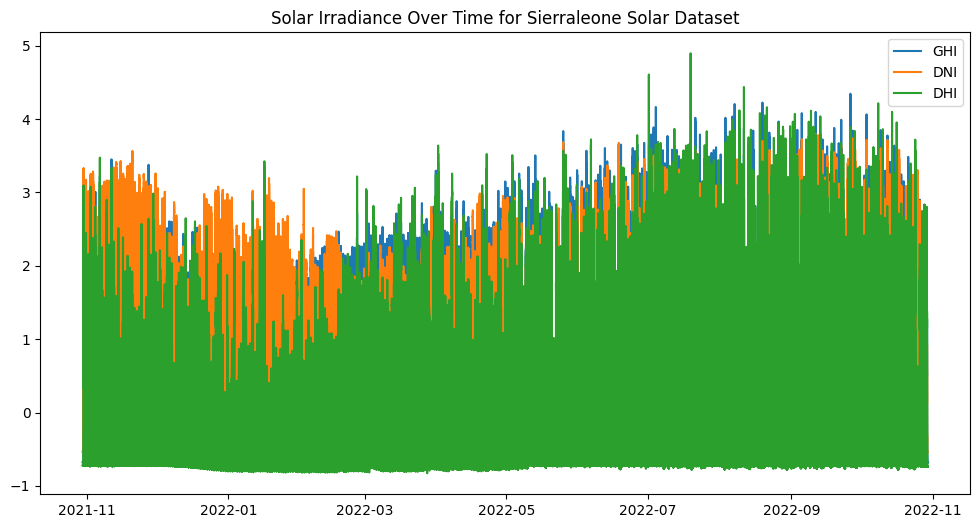

In [32]:
sierraleone["Timestamp"] = pd.to_datetime(sierraleone["Timestamp"])
plt.figure(figsize=(12, 6))
plt.plot(sierraleone["Timestamp"], sierraleone["GHI"], label="GHI")
plt.plot(sierraleone["Timestamp"], sierraleone["DNI"], label="DNI")
plt.plot(sierraleone["Timestamp"], sierraleone["DHI"], label="DHI")
plt.legend()
plt.title("Solar Irradiance Over Time for Sierraleone Solar Dataset")
plt.show()

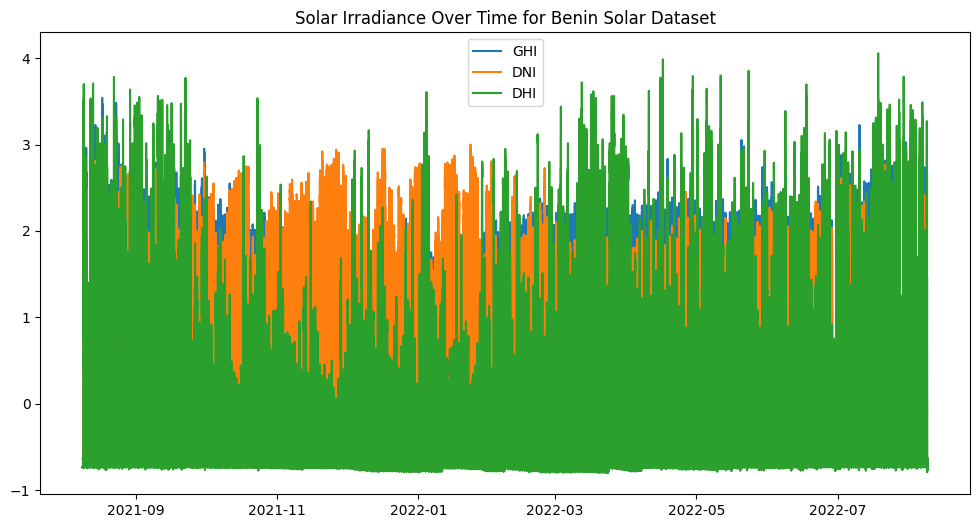

In [33]:
benin["Timestamp"] = pd.to_datetime(benin["Timestamp"])
plt.figure(figsize=(12, 6))
plt.plot(benin["Timestamp"], benin["GHI"], label="GHI")
plt.plot(benin["Timestamp"], benin["DNI"], label="DNI")
plt.plot(benin["Timestamp"], benin["DHI"], label="DHI")
plt.legend()
plt.title("Solar Irradiance Over Time for Benin Solar Dataset")
plt.show()

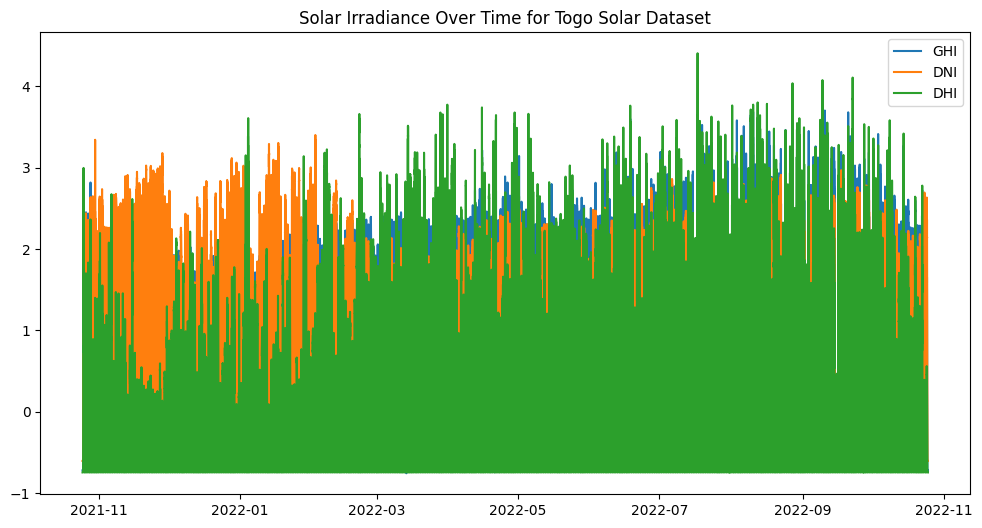

In [34]:
togo["Timestamp"] = pd.to_datetime(togo["Timestamp"])
plt.figure(figsize=(12, 6))
plt.plot(togo["Timestamp"], togo["GHI"], label="GHI")
plt.plot(togo["Timestamp"], togo["DNI"], label="DNI")
plt.plot(togo["Timestamp"], togo["DHI"], label="DHI")
plt.legend()
plt.title("Solar Irradiance Over Time for Togo Solar Dataset")
plt.show()

## Correlation & Relationship Analysis

> ### Generate a heatmap to visualize correlations:


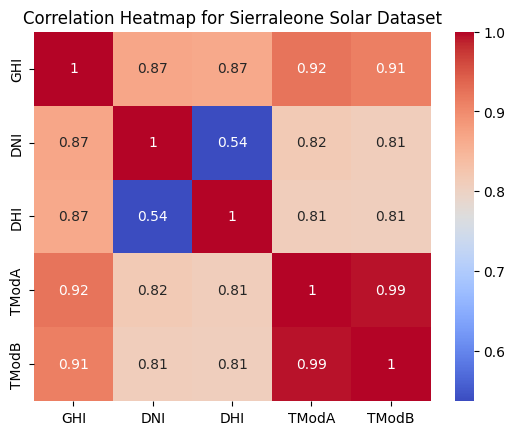

In [35]:
corr_matrix_s =  sierraleone[["GHI", "DNI", "DHI", "TModA", "TModB"]].corr()
sns.heatmap(corr_matrix_s, annot=True, cmap="coolwarm")
plt.title("Correlation Heatmap for Sierraleone Solar Dataset")
plt.show()

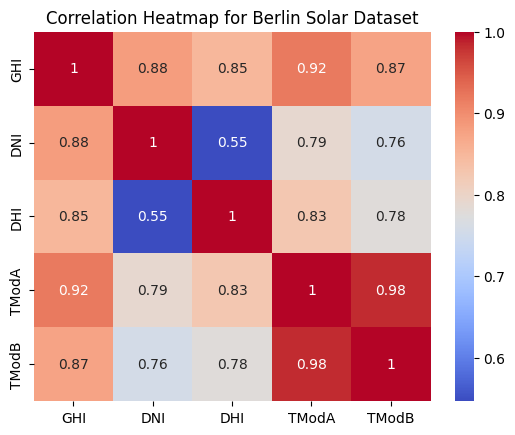

In [37]:
corr_matrix_b =  benin[["GHI", "DNI", "DHI", "TModA", "TModB"]].corr()
sns.heatmap(corr_matrix_b, annot=True, cmap="coolwarm")
plt.title("Correlation Heatmap for Berlin Solar Dataset")
plt.show()

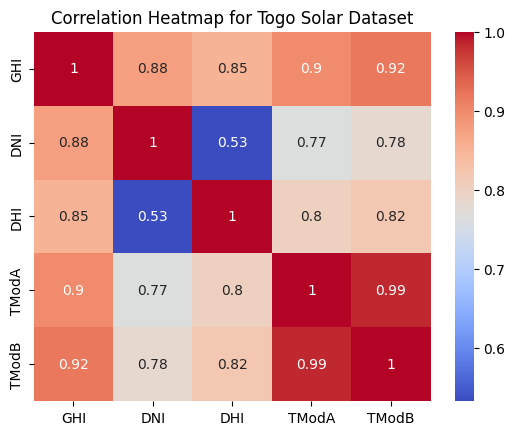

In [38]:
corr_matrix_t =  togo[["GHI", "DNI", "DHI", "TModA", "TModB"]].corr()
sns.heatmap(corr_matrix_t, annot=True, cmap="coolwarm")
plt.title("Correlation Heatmap for Togo Solar Dataset")
plt.show()

## Wind & Distribution Analysis

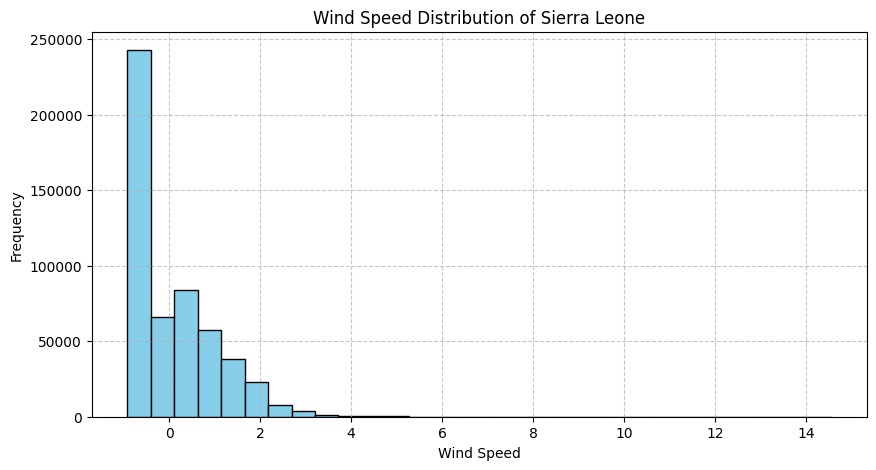

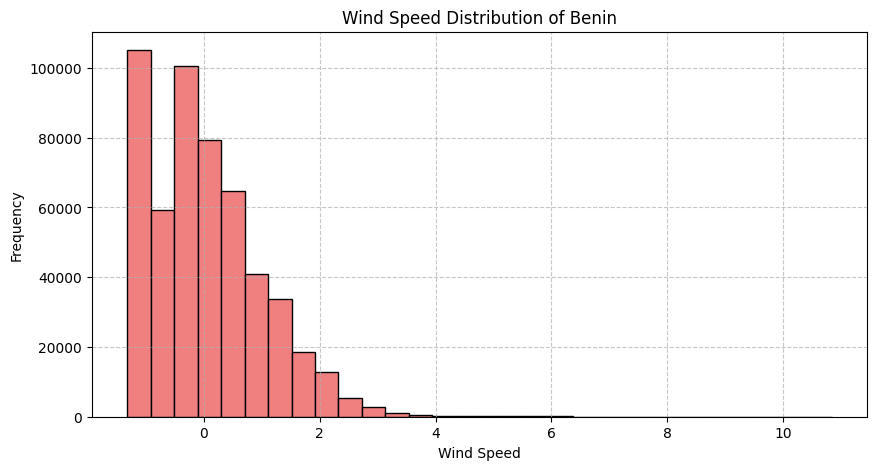

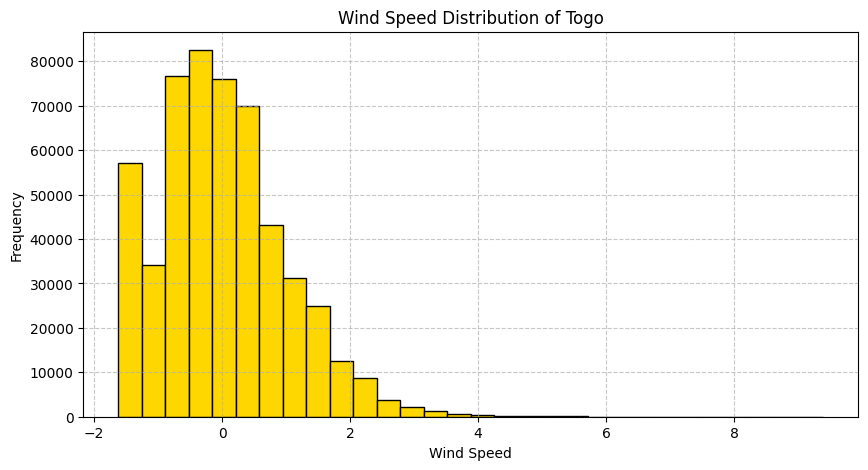

In [39]:

# Sierra Leone
plt.figure(figsize=(10, 5))
sierraleone["WS"].hist(bins=30, color="skyblue", edgecolor="black")
plt.title("Wind Speed Distribution of Sierra Leone")
plt.xlabel("Wind Speed")
plt.ylabel("Frequency")
plt.grid(True, linestyle="--", alpha=0.7)
plt.show()

# Benin
plt.figure(figsize=(10, 5))
benin["WS"].hist(bins=30, color="lightcoral", edgecolor="black")
plt.title("Wind Speed Distribution of Benin")
plt.xlabel("Wind Speed")
plt.ylabel("Frequency")
plt.grid(True, linestyle="--", alpha=0.7)
plt.show()

# Togo
plt.figure(figsize=(10, 5))
togo["WS"].hist(bins=30, color="gold", edgecolor="black")
plt.title("Wind Speed Distribution of Togo")
plt.xlabel("Wind Speed")
plt.ylabel("Frequency")
plt.grid(True, linestyle="--", alpha=0.7)
plt.show()

## Bubble Chart

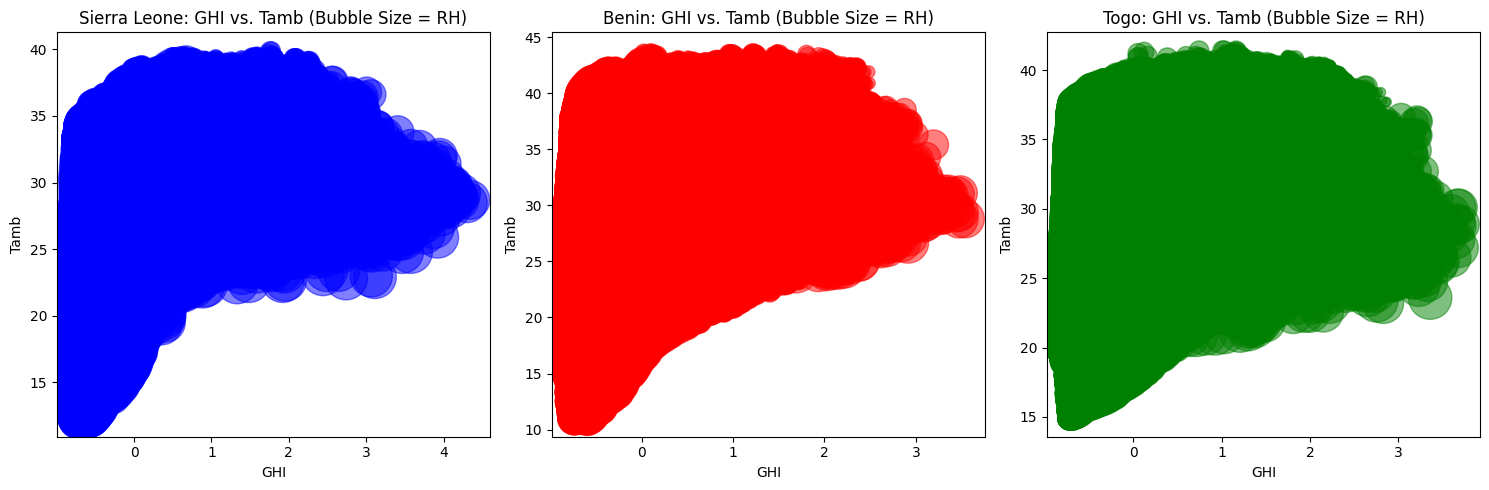

In [43]:
# Create figure with 3 subplots
fig, axes = plt.subplots(nrows=1, ncols=3, figsize=(15, 5))

# Sierra Leone Bubble Chart
axes[0].scatter(sierraleone["GHI"], sierraleone["Tamb"], s=sierraleone["RH"]*10, alpha=0.5, color="blue")
axes[0].set_xlabel("GHI")
axes[0].set_ylabel("Tamb")
axes[0].set_title("Sierra Leone: GHI vs. Tamb (Bubble Size = RH)")

# Benin Bubble Chart
axes[1].scatter(benin["GHI"], benin["Tamb"], s=benin["RH"]*10, alpha=0.5, color="red")
axes[1].set_xlabel("GHI")
axes[1].set_ylabel("Tamb")
axes[1].set_title("Benin: GHI vs. Tamb (Bubble Size = RH)")

# Togo Bubble Chart
axes[2].scatter(togo["GHI"], togo["Tamb"], s=togo["RH"]*10, alpha=0.5, color="green")
axes[2].set_xlabel("GHI")
axes[2].set_ylabel("Tamb")
axes[2].set_title("Togo: GHI vs. Tamb (Bubble Size = RH)")

# Adjust layout for clarity
plt.tight_layout()
plt.show()

## Cross-Country Comparison

C:\Users\girma\AppData\Local\Temp\ipykernel_1480\4271794736.py:5: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[0].boxplot([benin["DNI"], sierraleone["DNI"], togo["DNI"]], labels=["Benin", "Sierra Leone", "Togo"])
C:\Users\girma\AppData\Local\Temp\ipykernel_1480\4271794736.py:10: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[1].boxplot([benin["DHI"], sierraleone["DHI"], togo["DHI"]], labels=["Benin", "Sierra Leone", "Togo"])
C:\Users\girma\AppData\Local\Temp\ipykernel_1480\4271794736.py:15: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[2].boxplot([benin["GHI"], sierraleone["GHI"], togo["GHI"]], labels=[

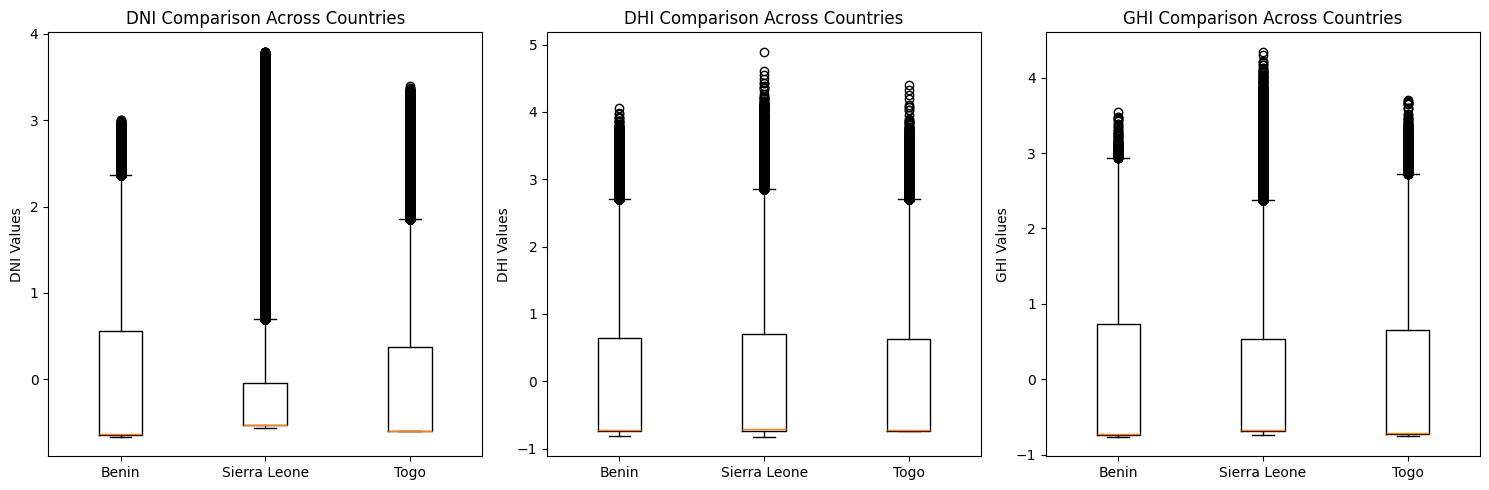

In [41]:
# Create a figure with 3 subplots
fig, axes = plt.subplots(nrows=1, ncols=3, figsize=(15, 5))

# Plot DNI comparison
axes[0].boxplot([benin["DNI"], sierraleone["DNI"], togo["DNI"]], labels=["Benin", "Sierra Leone", "Togo"])
axes[0].set_title("DNI Comparison Across Countries")
axes[0].set_ylabel("DNI Values")

# Plot DHI comparison
axes[1].boxplot([benin["DHI"], sierraleone["DHI"], togo["DHI"]], labels=["Benin", "Sierra Leone", "Togo"])
axes[1].set_title("DHI Comparison Across Countries")
axes[1].set_ylabel("DHI Values")

# Plot GHI comparison
axes[2].boxplot([benin["GHI"], sierraleone["GHI"], togo["GHI"]], labels=["Benin", "Sierra Leone", "Togo"])
axes[2].set_title("GHI Comparison Across Countries")
axes[2].set_ylabel("GHI Values")

# Adjust layout for readability
plt.tight_layout()
plt.show()